# Movement scores against the Abilium benchmark

The Discobox's original software ([Abilium-GmbH/varroa-discobox](https://github.com/Abilium-GmbH/varroa-discobox), `src/processing.py`, commit `cbf8c47`) decides which mites are alive like this, on the whole image of one recording:

1. read every frame in grayscale and denoise it (`cv2.fastNlMeansDenoising`, template 7, search 21);
2. **differential image**: the absolute difference between the first frame and each later one, combined with a bitwise OR;
3. threshold it at **25**, grow the spots (3x3 dilation, 5 times) and close the holes;
4. every contour of that mask is one mite counted as alive.

It never finds the mites themselves, only the spots that changed. To judge it on the same footing as the scores in `classes/analyzer.py`, this notebook asks it the same question for every labelled (mite, recording) of `calibration_data/`: **did this mite move?** A mite is called moving when a spot of Abilium's mask touches the mite's box.

Everything is compared with the ground truth entered by eye; *moving* is the positive class:

- **accuracy**: share of all calls that are right
- **precision**: of the calls "moving", the share that really moved
- **recall**: of the mites that really moved, the share called moving

Two comparisons are made, because a threshold picked on the same mites it is judged on looks better than it is:

- **as shipped**: this app's scores with the parameters and thresholds of `config.yaml`, Abilium with its 25. The `config.yaml` values were calibrated on these very mites, Abilium's 25 was not, so this one favours the app.
- **held out**: every threshold, Abilium's too, is picked on one half of the mites and judged on the other half.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path[:0] = [str(ROOT), str(ROOT / "scripts")]

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import pipeline
from classes import calibration
from classes.analyzer import Analyzer
from classes.app_config import get_default_config
from classes.data_loader import DataLoader
from optuna_metrics import split_halves
from tune_optical_flow import load_observations, score_all

# The project's reporting module switches matplotlib to Agg (no figures) on import.
%matplotlib inline

# Chart style: thin marks, recessive axes and grid, text in ink colours.
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8d8c85"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3dc"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "legend.fontsize": 8.5, "lines.linewidth": 2,
})

CONFIG = get_default_config().mite
ABILIUM = "Abilium"

## The labelled observations

The same observations a calibration scores: every (mite, recording) labelled moving or still, cut out as `config.yaml` has an analysis run cut it (plate stabilised or not, padded as each score asks).

In [2]:
METRICS = Analyzer.metric_names()
PARAMS = {metric: CONFIG.params_for(metric) for metric in METRICS}
PAD = {metric: Analyzer.roi_padding(metric, PARAMS[metric]) for metric in METRICS}

rois, moving, mites, recordings = load_observations(sorted(set(PAD.values())))
obs = pd.MultiIndex.from_arrays([mites, recordings], names=["mite", "recording"])
dataset_of = pd.Series([m.split("/")[0] for m in mites], index=obs)
in_a = split_halves(mites)

print(f"{len(moving)} observations: {moving.sum()} moving, {(~moving).sum()} still, "
      f"from {len(set(mites))} mites in {dataset_of.nunique()} datasets")
print(f"plate stabilised: {CONFIG.stabilize_plate}; metric in config.yaml: {CONFIG.metric}")

  ground_truth_60min: 32 mites


  sample_data: 29 mites


  ground_truth_90min: 28 mites
516 observations: 212 moving, 304 still, from 86 mites in 3 datasets
plate stabilised: True; metric in config.yaml: topN_variability


## Abilium's algorithm

`abilium_differential()` and `abilium_mask()` are steps 1 to 3 of `process_images()`, with the same calls and constants; only the drawing and the file handling are left out. They run on the whole frame, as there, with no plate stabilisation, since the original has none.

Three things are read from each recording:

- **the call** (`touch`): a spot of the mask lies on the mite's box. This is the benchmark.
- **the call by Abilium's own circle** (`circle`): the original draws a circle of radius 20 around each spot; here a mite is called moving when a spot's centre is within 20 px of the mite's. Given to show the result does not hang on the rule above.
- **a score**: the highest value of the differential image within the dilation's reach (5 px) of the box. It is above 25 exactly when a spot touches the box before the holes are closed, so it is Abilium's call with a movable threshold, which the ROC curve and the held-out comparison need.

Denoising 540 full frames takes a few minutes, so the differential images are kept in `calibration_data/reports/abilium_benchmark_diffs.npz`; delete that file to compute them again.

In [3]:
ABILIUM_THRESHOLD = 25   # cv2.threshold(differentialImage, 25, 255, cv2.THRESH_BINARY)
KERNEL = np.ones((3, 3), np.uint8)
GROW = 5                 # cv2.dilate(mask, kernel, iterations=5)
CIRCLE = 20              # cv2.circle(originals[i], center, 20, ...)


def abilium_differential(frames):
    # The first frame against every later one, denoised, OR-ed together (diffImg()).
    frames = [cv2.fastNlMeansDenoising(f, templateWindowSize=7, searchWindowSize=21) for f in frames]
    d = np.zeros(frames[0].shape, np.uint8)
    for frame in frames[1:]:
        d = cv2.bitwise_or(cv2.absdiff(frames[0], frame), d)
    return d


def abilium_mask(differential):
    _ret, mask = cv2.threshold(differential, ABILIUM_THRESHOLD, 255, cv2.THRESH_BINARY)
    mask = cv2.dilate(mask, KERNEL, iterations=GROW)
    return cv2.morphologyEx(mask, cv2.MORPH_CLOSE, KERNEL)


def abilium_spots(mask):
    # Centre of every contour: each is one mite Abilium counts as alive.
    contours, _hier = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    return np.array([cv2.minEnclosingCircle(c)[0] for c in contours]).reshape(-1, 2)


CACHE = pipeline.CALIBRATION_REPORTS / "abilium_benchmark_diffs.npz"
cached = dict(np.load(CACHE)) if CACHE.is_file() else {}

rows, counts = [], []
for summary in pipeline.list_calibration_datasets():
    dataset = pipeline._read_dataset(summary["id"], pipeline.CALIBRATION_LIBRARY)
    recordings_dir = pipeline._recordings_dir(dataset["data_dir"], pipeline.CALIBRATION_LIBRARY)
    if not recordings_dir.is_dir():
        continue
    loader = DataLoader(recordings_dir, grayscale=True)
    boxes = pipeline.mite_boxes(dataset["mites"])
    centres = {m["id"]: (m["x"], m["y"]) for m in dataset["mites"]}
    for index, recording in enumerate(dataset["recordings"]):
        key = f"{summary['id']}|{recording['name']}"
        if key not in cached:
            cached[key] = abilium_differential(loader.load_recording(recording["name"]))
        differential = cached[key]
        mask = abilium_mask(differential)
        reach = cv2.dilate(differential, KERNEL, iterations=GROW)
        spots = abilium_spots(mask)
        on_a_mite = np.zeros(len(spots), bool)
        for mite_id, (x1, y1, x2, y2) in boxes.items():
            box = np.s_[max(0, y1):y2, max(0, x1):x2]
            near = np.hypot(*(spots - centres[mite_id]).T) <= CIRCLE if len(spots) else np.zeros(0, bool)
            on_a_mite |= near
            rows.append({"mite": f"{summary['id']}/{mite_id}", "recording": index,
                         "touch": bool(mask[box].any()), "circle": bool(near.any()),
                         "score": float(reach[box].max())})
        counts.append({"dataset": dataset["name"], "recording": index,
                       "spots": len(spots), "spots on no detected mite": int((~on_a_mite).sum())})
    print(f"  {dataset['name']}: {len(dataset['recordings'])} recordings")

if len(cached) and not CACHE.is_file():
    np.savez_compressed(CACHE, **cached)

abilium = pd.DataFrame(rows).set_index(["mite", "recording"]).loc[obs]
score_call = abilium["score"] > ABILIUM_THRESHOLD
print(f"score > {ABILIUM_THRESHOLD} and the mask agree on {(score_call == abilium['touch']).sum()} of {len(abilium)} observations")

  ground_truth_60min: 6 recordings
  sample_data: 6 recordings
  ground_truth_90min: 6 recordings
score > 25 and the mask agree on 516 of 516 observations


## This app's scores

Every score of `classes/analyzer.py`, with its parameters from `config.yaml`.

In [4]:
scores = {metric: score_all(rois[PAD[metric]], metric, PARAMS[metric]) for metric in METRICS}
scores[ABILIUM] = abilium["score"].to_numpy()
# calibration calls moving at score >= threshold; Abilium at differential > 25.
thresholds = {metric: CONFIG.threshold_for(metric) for metric in METRICS}
thresholds[ABILIUM] = ABILIUM_THRESHOLD + 0.5


def judge(called, truth=moving):
    # Accuracy, precision and recall of calls against the labels; moving is positive.
    called, truth = np.asarray(called, bool), np.asarray(truth, bool)
    tp, fp = int((called & truth).sum()), int((called & ~truth).sum())
    fn, tn = int((~called & truth).sum()), int((~called & ~truth).sum())
    precision = tp / (tp + fp) if tp + fp else np.nan
    recall = tp / (tp + fn) if tp + fn else np.nan
    return {"accuracy": (tp + tn) / len(truth), "precision": precision, "recall": recall,
            "F1": 2 * precision * recall / (precision + recall) if tp else np.nan,
            "moving, called moving": tp, "still, called moving": fp,
            "moving, called still": fn, "still, called still": tn}


def show(table):
    rates = ["accuracy", "precision", "recall", "F1", "AUC"]
    style = table.style.format({c: "{:.3f}" for c in rates if c in table}, na_rep="")
    style = style.format({"threshold": "{:.4g}"}, na_rep="")
    display(style.apply(lambda row: ["font-weight: bold" if row.name.startswith(ABILIUM) else ""] * len(row), axis=1))

## As shipped

Each of this app's scores at its `config.yaml` threshold, Abilium at its 25. **AUC** needs no threshold: it is the chance that a mite that moved scores higher than one that did not.

Read it knowing that `config.yaml`'s thresholds and parameters were calibrated on these same mites.

In [5]:
calls = {name: scores[name] >= thresholds[name] for name in METRICS}
calls[f"{ABILIUM} (spot touches the mite)"] = abilium["touch"].to_numpy()
calls[f"{ABILIUM} (spot centre within {CIRCLE} px)"] = abilium["circle"].to_numpy()
score_of = lambda name: scores[ABILIUM if name.startswith(ABILIUM) else name]

shipped = pd.DataFrame({
    name: {"threshold": thresholds[ABILIUM if name.startswith(ABILIUM) else name] if "circle" not in name else np.nan,
           **judge(called), "AUC": calibration.auc(score_of(name), moving)}
    for name, called in calls.items()
}).T.sort_values("accuracy", ascending=False)
shipped.insert(0, "in use", ["config.yaml" if name == CONFIG.metric else "" for name in shipped.index])
for column in shipped.columns[-5:-1]:
    shipped[column] = shipped[column].astype(int)
shipped.loc[shipped.index.str.startswith(ABILIUM), "threshold"] = ABILIUM_THRESHOLD
shipped.loc[shipped.index.str.contains("centre within"), "AUC"] = np.nan
show(shipped)

,in use,threshold,accuracy,precision,recall,F1,"moving, called moving","still, called moving","moving, called still","still, called still",AUC
topN_variability,config.yaml,3.476,0.984496,0.985714,0.976415,0.981043,207,3,5,301,0.998247
topN_vector_temporal_range,,38.5,0.984496,1.000000,0.962264,0.980769,204,0,8,304,0.997991
variability,,3.476,0.984496,0.985714,0.976415,0.981043,207,3,5,301,0.998247
optical_flow,,0.1004,0.980620,0.980952,0.971698,0.976303,206,4,6,300,0.998619
topN_temporal_range,,28.4,0.980620,0.995098,0.957547,0.975962,203,1,9,303,0.998285
max_diff,,14,0.978682,0.980861,0.966981,0.973872,205,4,7,300,0.988502
vector_variance,,229.9,0.972868,0.990099,0.943396,0.966184,200,2,12,302,0.979922
mean_diff,,1.727,0.941860,0.973958,0.882075,0.925743,187,5,25,299,0.967260
vector_diff,,117.7,0.941860,0.969072,0.886792,0.926108,188,6,24,298,0.950456
Abilium (spot touches the mite),,25,0.936047,0.865306,1.000000,0.927790,212,33,0,271,0.997300


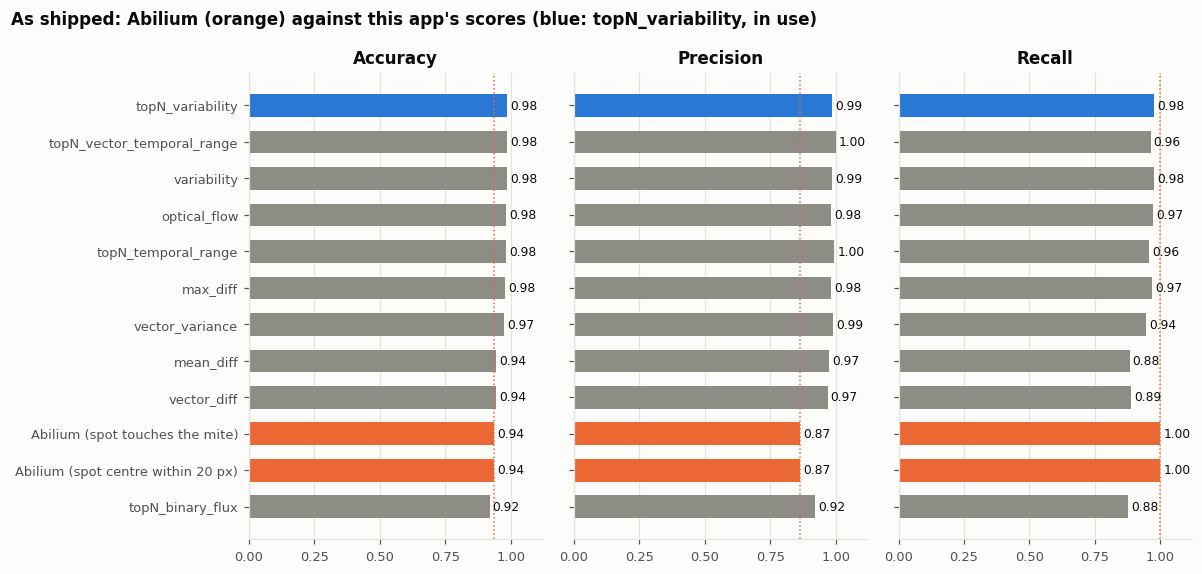

In [6]:
BENCH = f"{ABILIUM} (spot touches the mite)"
order = shipped.index[::-1]
fig, axes = plt.subplots(1, 3, figsize=(11, 0.34 * len(order) + 1.2), sharey=True)
for ax, rate in zip(axes, ["accuracy", "precision", "recall"]):
    values = shipped.loc[order, rate].astype(float)
    colours = [ORANGE if name.startswith(ABILIUM) else BLUE if name == CONFIG.metric else GREY for name in order]
    ax.barh(range(len(order)), values, color=colours, height=0.62)
    ax.axvline(shipped.loc[BENCH, rate], color=ORANGE, linewidth=1, linestyle=":")
    for y, value in enumerate(values):
        ax.text(value + 0.012, y, f"{value:.2f}", va="center", fontsize=8, color=INK)
    ax.set(title=rate.capitalize(), xlim=(0, 1.12), yticks=range(len(order)), yticklabels=order)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
    ax.grid(axis="y", visible=False)
fig.suptitle(f"As shipped: Abilium (orange) against this app's scores (blue: {CONFIG.metric}, in use)",
             x=0.01, ha="left", fontsize=11, fontweight="bold", color=INK)
fig.tight_layout()
plt.show()

## Held out

The fair comparison. The mites are split into two halves (by mite, so one mite's recordings never sit on both sides). Each method's threshold is picked on one half (Youden's J, as the calibration page does) and its calls are judged on the other half, then the halves swap; the table counts the calls of both. Abilium appears twice: with its own 25, which was never fitted to these mites, and with its threshold picked like the others'.

The *parameters* of this app's scores (`n`, `pad`, ...) are still those of `config.yaml`, searched on all the mites, so a small advantage remains on its side.

In [7]:
def held_out_calls(score):
    called = np.zeros(len(score), bool)
    picked = []
    for fit, test in ((in_a, ~in_a), (~in_a, in_a)):
        threshold = calibration.best_threshold(score[fit], moving[fit])
        called[test] = score[test] >= threshold
        picked.append(threshold)
    return called, picked


held_calls = {f"{ABILIUM} (threshold {ABILIUM_THRESHOLD}, as written)": abilium["touch"].to_numpy()}
picked = {}
for name in [*METRICS, ABILIUM]:
    label = f"{ABILIUM} (threshold picked)" if name == ABILIUM else name
    held_calls[label], picked[label] = held_out_calls(scores[name])

held = pd.DataFrame({name: judge(called) for name, called in held_calls.items()}).T
held.insert(0, "thresholds picked", [" / ".join(f"{t:.4g}" for t in picked[name]) if name in picked else "" for name in held.index])
for column in held.columns[-4:]:
    held[column] = held[column].astype(int)
held = held.sort_values("accuracy", ascending=False)
show(held)

,thresholds picked,accuracy,precision,recall,F1,"moving, called moving","still, called moving","moving, called still","still, called still"
Abilium (threshold picked),35 / 39,0.992248,0.990566,0.990566,0.990566,210,2,2,302
variability,3.588 / 3.456,0.982558,0.985646,0.971698,0.978622,206,3,6,301
topN_variability,3.588 / 3.456,0.982558,0.985646,0.971698,0.978622,206,3,6,301
max_diff,16 / 14,0.976744,0.980769,0.962264,0.971429,204,4,8,300
optical_flow,0.09312 / 0.1108,0.970930,0.966825,0.962264,0.964539,204,7,8,297
topN_vector_temporal_range,36 / 22.5,0.968992,0.962264,0.962264,0.962264,204,8,8,296
topN_temporal_range,29.75 / 19.4,0.965116,0.961905,0.952830,0.957346,202,8,10,296
vector_variance,233.5 / 110.4,0.953488,0.943396,0.943396,0.943396,200,12,12,292
"Abilium (threshold 25, as written)",,0.936047,0.865306,1.000000,0.927790,212,33,0,271
mean_diff,1.674 / 1.731,0.934109,0.954082,0.882075,0.916667,187,9,25,295


### Is the difference more than chance?

The observations are not independent: each mite gives up to six, and a mite that is hard to call is hard in every recording. So the mites, not the observations, are drawn again with replacement 5000 times, and each time the held-out accuracy of a score minus that of Abilium as written is taken. An interval that does not hold 0 is a difference the labelled mites can tell apart from chance.

In [8]:
REFERENCE = f"{ABILIUM} (threshold {ABILIUM_THRESHOLD}, as written)"
mite_codes, mite_names = pd.factorize(np.array(mites))
n_per_mite = np.bincount(mite_codes)
rng = np.random.default_rng(0)
draws = rng.integers(0, len(mite_names), size=(5000, len(mite_names)))


def accuracy_draws(called):
    right = np.bincount(mite_codes, weights=(called == moving).astype(float))
    return right[draws].sum(axis=1) / n_per_mite[draws].sum(axis=1)


reference = accuracy_draws(held_calls[REFERENCE])
rows = []
for name, called in held_calls.items():
    if name == REFERENCE:
        continue
    difference = accuracy_draws(called) - reference
    low, high = np.percentile(difference, [2.5, 97.5])
    rows.append({"method": name, "accuracy": (called == moving).mean(),
                 "minus Abilium": (called == moving).mean() - (held_calls[REFERENCE] == moving).mean(),
                 "95% low": low, "95% high": high,
                 "verdict": "better" if low > 0 else "worse" if high < 0 else "no clear difference"})
difference = pd.DataFrame(rows).set_index("method").sort_values("minus Abilium", ascending=False)
print(f"Abilium as written: accuracy {(held_calls[REFERENCE] == moving).mean():.3f} "
      f"(95% {np.percentile(reference, 2.5):.3f} to {np.percentile(reference, 97.5):.3f})")
retuned = accuracy_draws(held_calls[f"{ABILIUM} (threshold picked)"]) - accuracy_draws(held_calls[CONFIG.metric])
print(f"Abilium with its threshold picked minus {CONFIG.metric}: {retuned.mean():+.3f} "
      f"(95% {np.percentile(retuned, 2.5):+.3f} to {np.percentile(retuned, 97.5):+.3f})")
display(difference.style.format({c: "{:+.3f}" for c in ["minus Abilium", "95% low", "95% high"]} | {"accuracy": "{:.3f}"}))

Abilium as written: accuracy 0.936 (95% 0.911 to 0.959)
Abilium with its threshold picked minus topN_variability: +0.010 (95% -0.002 to +0.021)


,accuracy,minus Abilium,95% low,95% high,verdict
method,,,,,
Abilium (threshold picked),0.992,+0.056,+0.033,+0.081,better
variability,0.983,+0.047,+0.023,+0.070,better
topN_variability,0.983,+0.047,+0.023,+0.070,better
max_diff,0.977,+0.041,+0.017,+0.064,better
optical_flow,0.971,+0.035,+0.014,+0.058,better
topN_vector_temporal_range,0.969,+0.033,+0.014,+0.052,better
topN_temporal_range,0.965,+0.029,+0.010,+0.048,better
vector_variance,0.953,+0.017,-0.002,+0.037,no clear difference
mean_diff,0.934,-0.002,-0.037,+0.029,no clear difference


## Across every threshold

The ROC curve shows each method at all its thresholds at once: up is more of the moving mites found (recall), right is more still mites wrongly called moving. The dot is where Abilium's 25 puts it.

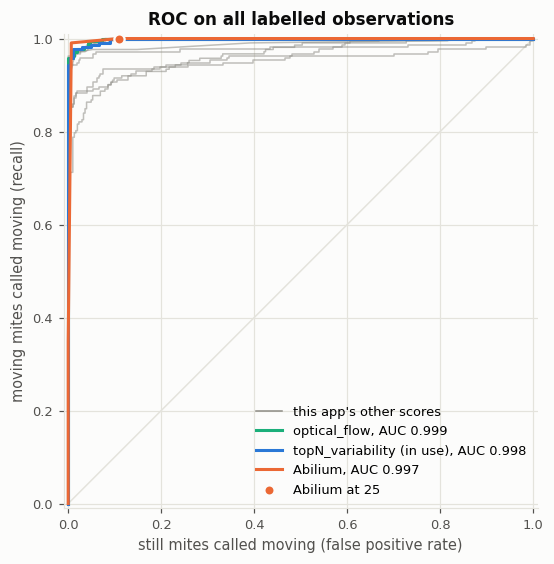

In [9]:
fig, ax = plt.subplots(figsize=(6.2, 5.6))
ax.plot([0, 1], [0, 1], color=GRID, linewidth=1)
ranked = sorted(METRICS, key=lambda m: calibration.auc(scores[m], moving))
best = ranked[-1] if ranked[-1] != CONFIG.metric else ranked[-2]
for metric in ranked:
    if metric in (CONFIG.metric, best):
        continue
    fpr, tpr, _ = calibration.roc_curve(scores[metric], moving)
    ax.plot(fpr, tpr, color=GREY, linewidth=1, alpha=0.55)
ax.plot([], [], color=GREY, linewidth=1, label="this app's other scores")
for metric, colour in ((best, AQUA), (CONFIG.metric, BLUE), (ABILIUM, ORANGE)):
    fpr, tpr, _ = calibration.roc_curve(scores[metric], moving)
    note = " (in use)" if metric == CONFIG.metric else ""
    ax.plot(fpr, tpr, color=colour, label=f"{metric}{note}, AUC {calibration.auc(scores[metric], moving):.3f}")
point = judge(abilium["touch"].to_numpy())
ax.scatter([point["still, called moving"] / (~moving).sum()], [point["recall"]], color=ORANGE, zorder=5, s=45,
           edgecolor="#fcfcfb", linewidth=1.5, label=f"Abilium at {ABILIUM_THRESHOLD}")
ax.set(xlabel="still mites called moving (false positive rate)", ylabel="moving mites called moving (recall)",
       title="ROC on all labelled observations", xlim=(-0.01, 1.01), ylim=(-0.01, 1.01), aspect="equal")
ax.legend(loc="lower right")
plt.show()

## Where Abilium goes wrong

Its calls per dataset, and the same for the score in use, both as shipped.

In [10]:
rows = {}
for dataset in dataset_of.unique():
    here = (dataset_of == dataset).to_numpy()
    for name in (BENCH, CONFIG.metric):
        result = judge(calls[name][here], moving[here])
        rows[dataset.rsplit("-", 1)[0], name] = {k: result[k] for k in list(result)[:3] + list(result)[4:]}
by_dataset = pd.DataFrame(rows).T
for column in by_dataset.columns[3:]:
    by_dataset[column] = by_dataset[column].astype(int)
display(by_dataset.style.format({c: "{:.3f}" for c in ["accuracy", "precision", "recall"]}))

### The number Abilium reports

The original does not call single mites: per recording it reports the number of spots as "varroa alive". Below, per dataset and averaged over its recordings: that number, how many of the spots lie on no mite the app detected (reflections, plate edges, dirt, or a mite the detector missed), and the number of mites labelled moving. Mites left unlabelled are not in the last column, so the columns are a rough comparison only.

In [11]:
counted = pd.DataFrame(counts)
truth_moving = (pd.Series(moving, index=obs).groupby([dataset_of.str.rsplit("-", n=1).str[0].to_numpy(), obs.get_level_values("recording")]).sum())
counted["labelled moving"] = [truth_moving.get((d, r), 0) for d, r in zip(counted["dataset"], counted["recording"])]
display(counted.groupby("dataset")[["spots", "spots on no detected mite", "labelled moving"]].mean().round(1)
        .rename(columns={"spots": "Abilium's \"alive\" count"}))

,"Abilium's ""alive"" count",spots on no detected mite,labelled moving
dataset,,,
ground_truth_60min,14.3,0.3,12.5
ground_truth_90min,13.0,0.2,10.7
sample_data,14.3,0.3,12.2


### What each circle was drawn around

Every contour of the mask gets a circle and counts as one mite alive. Each circle of every recording is put in one category, by what the spot lies on (the first that applies):

- **a mite that moved**: a detected mite labelled moving in that recording. The circle is right.
- **a still mite**: a detected mite labelled still. A dead mite counted as alive.
- **a mite left unlabelled**: a detected mite with no label for that recording, so the circle cannot be judged.
- **a detection marked "not a mite"**: something the app's detector also took for a mite and you rejected.
- **nothing detected**: no detection of the app within the spot. Either no mite at all, or a mite the app's detector missed; the pictures further down show which.
- **a hole inside another spot**: `cv2.findContours(..., RETR_TREE)` also returns the inner edge of a ring-shaped spot, and the original counts it as one more mite.

A spot lying on two mites still gets one circle; `mites under one circle` counts the mites that are counted once too few for that reason.

In [12]:
CATEGORIES = ["a mite that moved", "a still mite", "a mite left unlabelled",
              "a detection marked \"not a mite\"", "nothing detected", "a hole inside another spot"]

circles, empty_spots = [], []
for summary in pipeline.list_calibration_datasets():
    dataset = pipeline._read_dataset(summary["id"], pipeline.CALIBRATION_LIBRARY)
    recordings_dir = pipeline._recordings_dir(dataset["data_dir"], pipeline.CALIBRATION_LIBRARY)
    if not recordings_dir.is_dir():
        continue
    n_recordings = len(dataset["recordings"])
    boxes = pipeline.mite_boxes(dataset["mites"])
    truth = {m["id"]: calibration.per_recording(dataset["truth"].get(m["id"]), n_recordings) for m in dataset["mites"]}
    for index, recording in enumerate(dataset["recordings"]):
        mask = abilium_mask(cached[f"{summary['id']}|{recording['name']}"])
        _n, spot_of = cv2.connectedComponents(mask)
        # Which mites each spot lies on, by the state of each in this recording.
        states_on = {}
        for mite_id, (x1, y1, x2, y2) in boxes.items():
            state = calibration.NOT_A_MITE if calibration.is_rejected(truth[mite_id]) else truth[mite_id][index]
            for spot in np.unique(spot_of[max(0, y1):y2, max(0, x1):x2]):
                if spot:
                    states_on.setdefault(spot, []).append(state)
        contours, hierarchy = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        for contour, (_next, _previous, _child, parent) in zip(contours, hierarchy[0] if contours else []):
            (x, y), _radius = cv2.minEnclosingCircle(contour)
            states = states_on.get(spot_of[contour[0, 0, 1], contour[0, 0, 0]], [])
            if parent >= 0:
                category = CATEGORIES[5]
            elif calibration.MOVING in states:
                category = CATEGORIES[0]
            elif calibration.STILL in states:
                category = CATEGORIES[1]
            elif None in states:
                category = CATEGORIES[2]
            elif states:
                category = CATEGORIES[3]
            else:
                category = CATEGORIES[4]
            real = [s for s in states if s != calibration.NOT_A_MITE]
            circles.append({"dataset": dataset["name"], "recording": index, "category": category,
                            "mites under one circle": max(0, len(real) - 1) if parent < 0 else 0})
            if category == CATEGORIES[4]:
                empty_spots.append((dataset["name"], recordings_dir, recording["name"], index, int(x), int(y)))

circles = pd.DataFrame(circles)
by_category = (circles.groupby(["category", "dataset"]).size().unstack(fill_value=0)
               .reindex(CATEGORIES, fill_value=0))
by_category["all"] = by_category.sum(axis=1)
by_category["share"] = by_category["all"] / len(circles)
display(by_category.style.format({"share": "{:.1%}"}))

n_recordings = circles.groupby(["dataset", "recording"]).ngroups
no_mite = by_category.loc[[CATEGORIES[3], CATEGORIES[4], CATEGORIES[5]], "all"].sum()
print(f"{len(circles)} circles in {n_recordings} recordings ({len(circles) / n_recordings:.1f} per recording)")
print(f"  on a mite that moved:            {by_category.loc[CATEGORIES[0], 'all']}")
print(f"  on a still mite:                 {by_category.loc[CATEGORIES[1], 'all']}")
print(f"  on no labelled mite at all:      {no_mite + by_category.loc[CATEGORIES[2], 'all']}"
      f"  (of them {by_category.loc[CATEGORIES[4], 'all']} where the app detected nothing)")
print(f"  mites sharing a circle with another (counted once too few): {circles['mites under one circle'].sum()}")

dataset,ground_truth_60min,ground_truth_90min,sample_data,all,share
category,,,,,
a mite that moved,75,64,73,212,84.8%
a still mite,9,13,11,33,13.2%
a mite left unlabelled,0,0,0,0,0.0%
"a detection marked ""not a mite""",0,0,0,0,0.0%
nothing detected,2,1,2,5,2.0%
a hole inside another spot,0,0,0,0,0.0%


250 circles in 18 recordings (13.9 per recording)
  on a mite that moved:            212
  on a still mite:                 33
  on no labelled mite at all:      5  (of them 5 where the app detected nothing)
  mites sharing a circle with another (counted once too few): 0


The circles drawn where the app detected nothing, each on the first frame of its recording (80 px across, the circle as Abilium draws it). Look at them to tell a mite the detector missed from no mite at all.

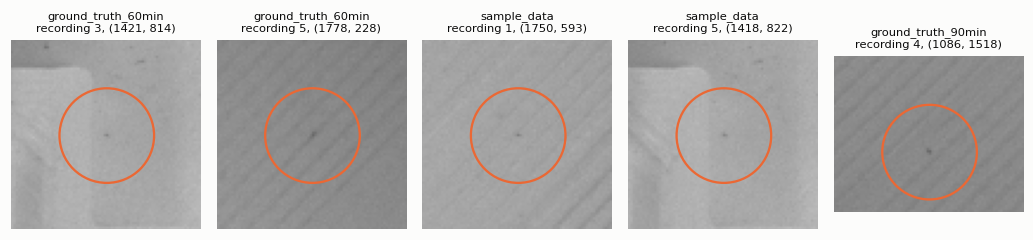

In [13]:
if empty_spots:
    HALF = 40
    columns = min(6, len(empty_spots))
    lines = -(-len(empty_spots) // columns)
    fig, axes = plt.subplots(lines, columns, figsize=(1.9 * columns, 2.15 * lines), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, (name, recordings_dir, recording, index, x, y) in zip(axes.ravel(), empty_spots):
        x0, y0 = max(0, x - HALF), max(0, y - HALF)
        frame = DataLoader(recordings_dir, grayscale=True).load_recording_region(recording, x0, y0, x + HALF, y + HALF, count=1)[0]
        ax.imshow(frame, cmap="gray", vmin=0, vmax=255)
        ax.add_patch(plt.Circle((x - x0, y - y0), CIRCLE, fill=False, color=ORANGE, linewidth=1.5))
        ax.set_title(f"{name}\nrecording {index + 1}, ({x}, {y})", fontsize=7.5, fontweight="normal")
    fig.tight_layout()
    plt.show()
else:
    print("No circle was drawn where the app detected nothing.")

## Summary

In [14]:
def line(name, row):
    return f"  {name:<44} accuracy {row['accuracy']:.3f}   precision {row['precision']:.3f}   recall {row['recall']:.3f}"

print(f"{len(moving)} labelled observations ({moving.sum()} moving, {(~moving).sum()} still) of {len(set(mites))} mites\n")
print("As shipped (config.yaml thresholds; fitted on these mites):")
for name in dict.fromkeys((BENCH, CONFIG.metric, shipped.index[~shipped.index.str.startswith(ABILIUM)][0])):
    print(line(name, shipped.loc[name]))
print("\nHeld out (thresholds picked on the other half of the mites):")
for name in dict.fromkeys((REFERENCE, f"{ABILIUM} (threshold picked)", CONFIG.metric, held.index[~held.index.str.startswith(ABILIUM)][0])):
    print(line(name, held.loc[name]))

516 labelled observations (212 moving, 304 still) of 86 mites

As shipped (config.yaml thresholds; fitted on these mites):
  Abilium (spot touches the mite)              accuracy 0.936   precision 0.865   recall 1.000
  topN_variability                             accuracy 0.984   precision 0.986   recall 0.976

Held out (thresholds picked on the other half of the mites):
  Abilium (threshold 25, as written)           accuracy 0.936   precision 0.865   recall 1.000
  Abilium (threshold picked)                   accuracy 0.992   precision 0.991   recall 0.991
  topN_variability                             accuracy 0.983   precision 0.986   recall 0.972
  variability                                  accuracy 0.983   precision 0.986   recall 0.972
